In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [4]:
print("Fund Master :", fund.shape)
print("NAV History :", nav.shape)
print("Performance :", performance.shape)
print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
Performance : (40, 20)
Benchmark : (8050, 3)


In [5]:
nav['date'] = pd.to_datetime(nav['date'])

benchmark['date'] = pd.to_datetime(benchmark['date'])

In [6]:
print(nav.dtypes)

print()

print(benchmark.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

date           datetime64[ns]
index_name             object
close_value           float64
dtype: object


In [7]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [9]:
print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [10]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [11]:
print(nav['daily_return'].isnull().sum())

40


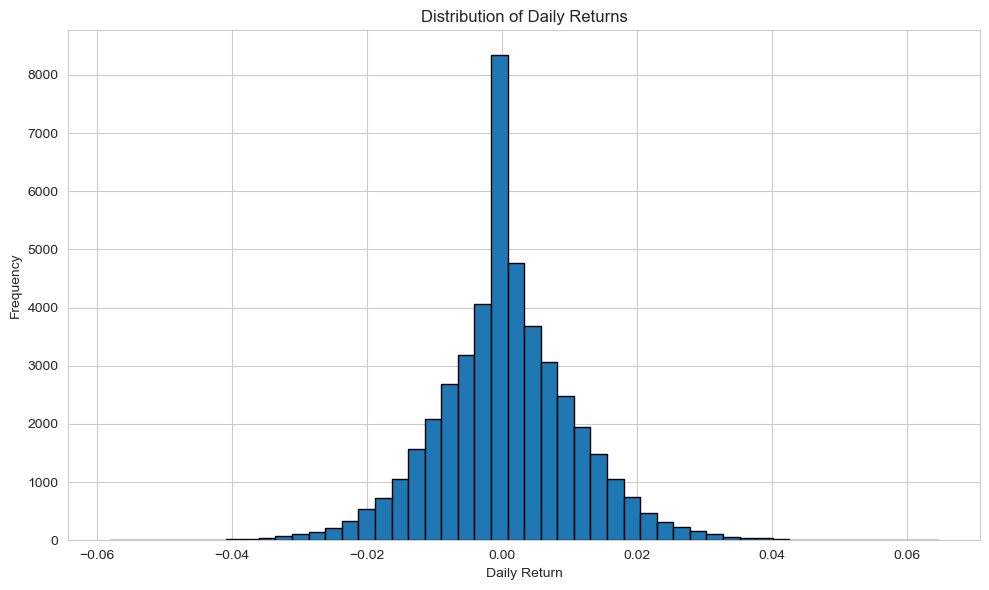

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    nav['daily_return'].dropna(),
    bins=50,
    edgecolor='black'
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

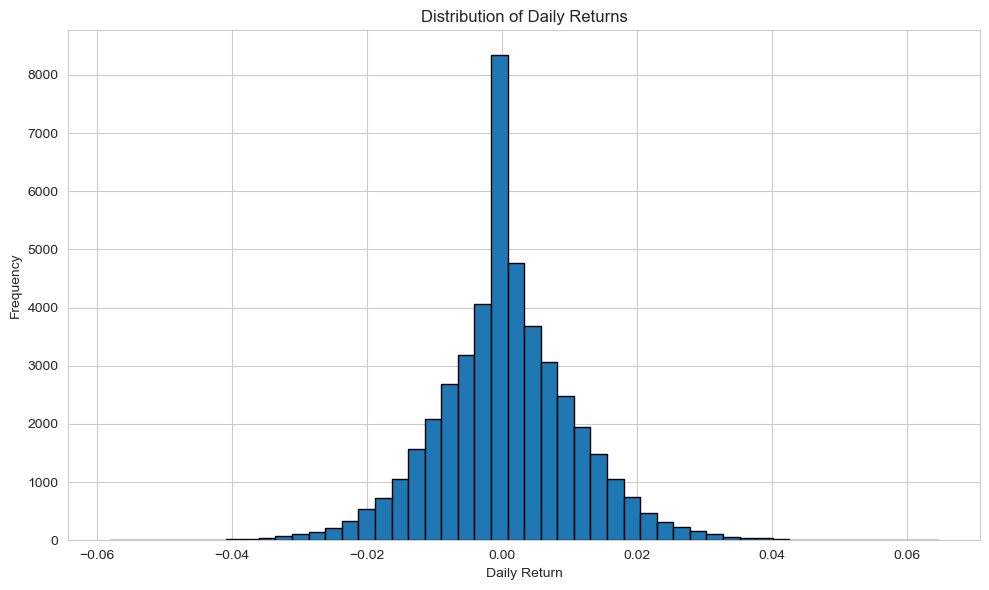

In [13]:
plt.figure(figsize=(10,6))

plt.hist(
    nav['daily_return'].dropna(),
    bins=50,
    edgecolor='black'
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../reports/charts/daily_return_distribution.png")

plt.show()

In [14]:
nav.to_csv(
    "../data/processed/daily_returns.csv",
    index=False
)

print("Daily Returns Saved Successfully")

Daily Returns Saved Successfully


## Insight

The daily return distribution is centered around zero, indicating that most NAV changes are small on a day-to-day basis. Positive and negative returns are reasonably balanced, with only a few extreme movements, suggesting a realistic return distribution for the selected mutual fund schemes.

In [15]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

In [16]:
cagr_data = []

In [17]:
for fund_code in nav['amfi_code'].unique():

    fund_nav = nav[
        nav['amfi_code'] == fund_code
    ].sort_values('date')

    start_nav = fund_nav.iloc[0]['nav']

    end_nav = fund_nav.iloc[-1]['nav']

    years = (
        (fund_nav.iloc[-1]['date'] -
         fund_nav.iloc[0]['date']).days
    ) / 365.25

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    cagr_data.append([
        fund_code,
        start_nav,
        end_nav,
        years,
        cagr
    ])

In [18]:
cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        'amfi_code',
        'start_nav',
        'end_nav',
        'years',
        'cagr'
    ]
)

In [19]:
cagr_df['cagr_percent'] = (
    cagr_df['cagr'] * 100
).round(2)

In [20]:
cagr_df = cagr_df.merge(
    fund[
        ['amfi_code', 'scheme_name']
    ],
    on='amfi_code',
    how='left'
)

In [21]:
cagr_df = cagr_df[
    [
        'amfi_code',
        'scheme_name',
        'start_nav',
        'end_nav',
        'years',
        'cagr_percent'
    ]
]

In [22]:
cagr_df.head(10)

,amfi_code,scheme_name,start_nav,end_nav,years,cagr_percent
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,520.4608,583.6113,4.399726,2.64
1,100025,HDFC Short Term Debt Fund - Regular - Growth,26.3169,31.8843,4.399726,4.46
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.3758,342.0072,4.399726,30.12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,305.0996,773.2939,4.399726,23.54
4,101207,ABSL Small Cap Fund - Regular - Growth,38.5736,53.9836,4.399726,7.94
5,101208,ABSL Liquid Fund - Regular - Growth,310.7415,410.1021,4.399726,6.51
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,89.8728,187.7797,4.399726,18.23
7,102886,UTI Mid Cap Fund - Regular - Growth,119.2905,125.5640,4.399726,1.17
8,102887,UTI Flexi Cap Fund - Regular - Growth,191.0721,378.9657,4.399726,16.84
9,118632,Nippon India Large Cap Fund - Regular - Growth,42.8339,110.5554,4.399726,24.05


In [23]:
top10 = cagr_df.sort_values(
    'cagr_percent',
    ascending=False
).head(10)

top10

,amfi_code,scheme_name,start_nav,end_nav,years,cagr_percent
25,120505,ICICI Pru Midcap Fund - Regular - Growth,135.8720,473.7640,4.399726,32.83
21,119598,SBI Small Cap Fund - Regular Plan - Growth,89.8738,309.2050,4.399726,32.42
39,149324,DSP Small Cap Fund - Regular - Growth,81.6814,279.7511,4.399726,32.29
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.8620,97.7435,4.399726,31.95
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,70.2514,230.2708,4.399726,30.97
30,120843,Kotak Flexicap Fund - Regular - Growth,49.9131,163.2397,4.399726,30.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.3758,342.0072,4.399726,30.12
38,149323,DSP Midcap Fund - Regular - Growth,78.4622,245.3651,4.399726,29.58
16,119094,Axis Midcap Fund - Regular - Growth,68.3023,203.8581,4.399726,28.21
19,119551,SBI Bluechip Fund - Regular Plan - Growth,54.3856,149.3216,4.399726,25.80


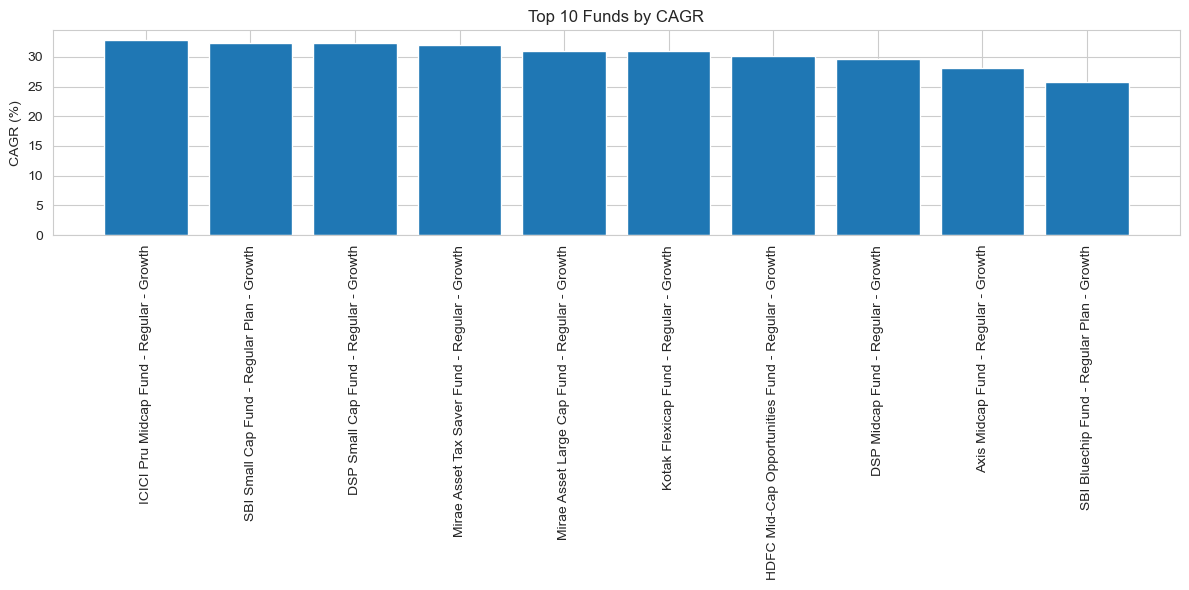

In [24]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['cagr_percent']
)

plt.xticks(
    rotation=90
)

plt.ylabel("CAGR (%)")

plt.title("Top 10 Funds by CAGR")

plt.tight_layout()

plt.show()

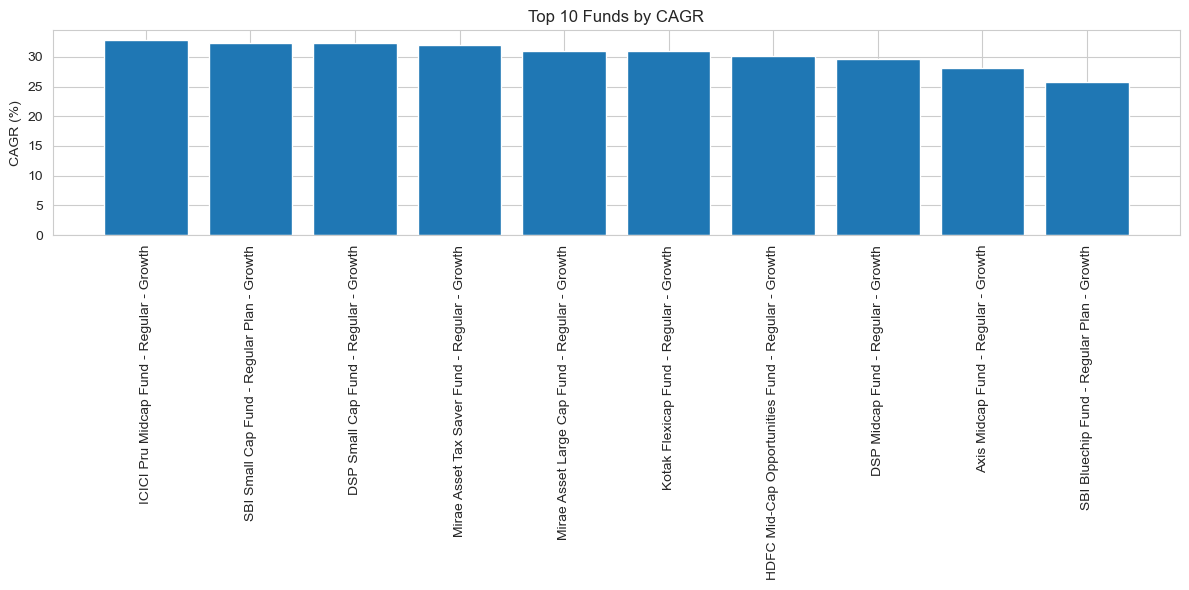

In [25]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['cagr_percent']
)

plt.xticks(
    rotation=90
)

plt.ylabel("CAGR (%)")

plt.title("Top 10 Funds by CAGR")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_cagr.png"
)

plt.show()

In [26]:
cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

print("CAGR Table Saved Successfully")

CAGR Table Saved Successfully


## Insight

The CAGR analysis shows the annualized growth achieved by each mutual fund over the available investment period. Funds with higher CAGR values have delivered stronger long-term growth, making them attractive for investors seeking wealth creation over multiple years.

In [27]:
risk_free_rate = 0.065

sharpe_data = []

for fund_code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code']==fund_code]

    returns = df['daily_return'].dropna()

    avg_return = returns.mean()*252

    std_return = returns.std()*np.sqrt(252)

    sharpe = (avg_return-risk_free_rate)/std_return

    sharpe_data.append([fund_code,sharpe])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=['amfi_code','sharpe_ratio']
)

In [28]:
sharpe_df = sharpe_df.merge(
    fund[['amfi_code','scheme_name']],
    on='amfi_code'
)

sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

sharpe_df.head()

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth


In [29]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [30]:
sortino_data=[]

for fund_code in nav['amfi_code'].unique():

    df=nav[nav['amfi_code']==fund_code]

    returns=df['daily_return'].dropna()

    downside=returns[returns<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=returns.mean()*252

    sortino=(annual_return-0.065)/downside_std

    sortino_data.append([fund_code,sortino])

sortino_df=pd.DataFrame(
    sortino_data,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df=sortino_df.merge(
    fund[['amfi_code','scheme_name']],
    on='amfi_code'
)

sortino_df=sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
)

sortino_df.head()

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth


In [31]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [32]:
benchmark100=benchmark[
    benchmark['index_name']=="NIFTY100"
].copy()

benchmark100=benchmark100.sort_values('date')

benchmark100['benchmark_return']=benchmark100['close_value'].pct_change()

In [33]:
alpha_beta=[]

for code in nav['amfi_code'].unique():

    df=nav[
        nav['amfi_code']==code
    ][['date','daily_return']]

    merged=df.merge(
        benchmark100[['date','benchmark_return']],
        on='date'
    ).dropna()

    slope,intercept,r,p,std=linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha=intercept*252

    beta=slope

    alpha_beta.append([
        code,
        alpha,
        beta,
        r**2
    ])

alpha_beta_df=pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta',
        'r_squared'
    ]
)

alpha_beta_df=alpha_beta_df.merge(
    fund[['amfi_code','scheme_name']],
    on='amfi_code'
)

alpha_beta_df.head()

,amfi_code,alpha,beta,r_squared,scheme_name
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth


In [34]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [35]:
drawdown=[]

for code in nav['amfi_code'].unique():

    df=nav[
        nav['amfi_code']==code
    ].copy()

    df['running_max']=df['nav'].cummax()

    df['drawdown']=(
        df['nav']/df['running_max']
    )-1

    max_dd=df['drawdown'].min()

    drawdown.append([
        code,
        max_dd
    ])

drawdown_df=pd.DataFrame(
    drawdown,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df=drawdown_df.merge(
    fund[['amfi_code','scheme_name']],
    on='amfi_code'
)

drawdown_df.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [36]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [37]:
score=fund[
    ['amfi_code',
     'scheme_name',
     'expense_ratio_pct']
]

score=score.merge(
    cagr_df[['amfi_code','cagr_percent']],
    on='amfi_code'
)

score=score.merge(
    sharpe_df[['amfi_code','sharpe_ratio']],
    on='amfi_code'
)

score=score.merge(
    alpha_beta_df[['amfi_code','alpha']],
    on='amfi_code'
)

score=score.merge(
    drawdown_df[['amfi_code','max_drawdown']],
    on='amfi_code'
)

In [38]:
score['return_rank']=score['cagr_percent'].rank(ascending=False)

score['sharpe_rank']=score['sharpe_ratio'].rank(ascending=False)

score['alpha_rank']=score['alpha'].rank(ascending=False)

score['expense_rank']=score['expense_ratio_pct'].rank()

score['dd_rank']=score['max_drawdown'].rank(ascending=False)

In [39]:
score['fund_score']=(
0.30*score['return_rank']+
0.25*score['sharpe_rank']+
0.20*score['alpha_rank']+
0.15*score['expense_rank']+
0.10*score['dd_rank']
)

score=score.sort_values(
    'fund_score'
)

score.head()

,amfi_code,scheme_name,expense_ratio_pct,cagr_percent,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,32.83,1.180101,0.292636,-0.181885,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,30.97,1.448291,0.269838,-0.112657,5.0,1.0,7.0,23.0,8.0,7.400
22,120843,Kotak Flexicap Fund - Regular - Growth,1.45,30.91,1.306744,0.273305,-0.129740,6.0,2.0,5.0,22.0,13.0,7.900
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,30.12,1.093699,0.271954,-0.162172,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,31.95,1.234930,0.282704,-0.163967,4.0,3.0,4.0,36.5,21.0,10.325


In [40]:
score.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [41]:
top5=score.head()['amfi_code']

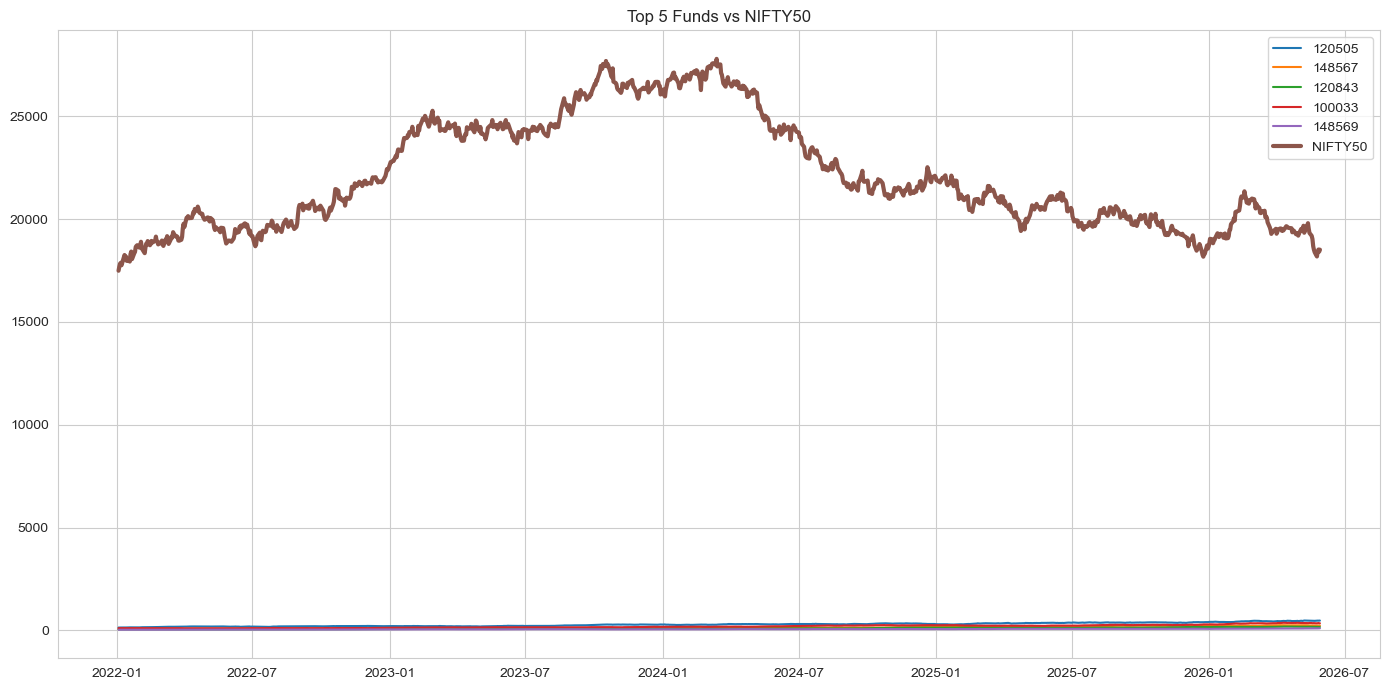

In [42]:
plt.figure(figsize=(14,7))

for code in top5:

    df=nav[
        nav['amfi_code']==code
    ]

    plt.plot(
        df['date'],
        df['nav'],
        label=str(code)
    )

nifty50=benchmark[
    benchmark['index_name']=="NIFTY50"
]

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    linewidth=3,
    label='NIFTY50'
)

plt.legend()

plt.title("Top 5 Funds vs NIFTY50")

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()